This notebook explores unsupervised ML models to detect insider threat. It will explain different concepts before implementation. It uses open source data set to explore this possibility.

Let's explore data.

In [28]:
!--%pip install pandas
import pandas as pd

df_logon = pd.read_csv("C:\\Users\\mj4059\\Downloads\\r5.2\\r5.2\\logon.csv")
print(df_logon.head())
print(df_logon.info())
print(df_logon.describe(include='all'))

'--%pip' is not recognized as an internal or external command,
operable program or batch file.


                         id                 date     user       pc activity
0  {Q4D5-W4HH44UC-5188LWZK}  01/02/2010 02:24:51  JBI1134  PC-0168    Logon
1  {G7V0-S4TP95SA-9203AOGR}  01/02/2010 02:38:28  JBI1134  PC-0168   Logoff
2  {B4U7-K4DB84LM-2657VBFY}  01/02/2010 04:55:52  JBI1134  PC-2320    Logon
3  {K2E1-W7VG04OA-3686THSV}  01/02/2010 05:02:28  JBI1134  PC-2320   Logoff
4  {Z7B2-Z8AS75YE-4485NAFE}  01/02/2010 06:35:00  HMI1448  PC-9352    Logon
<class 'pandas.DataFrame'>
RangeIndex: 1810070 entries, 0 to 1810069
Data columns (total 5 columns):
 #   Column    Dtype
---  ------    -----
 0   id        str  
 1   date      str  
 2   user      str  
 3   pc        str  
 4   activity  str  
dtypes: str(5)
memory usage: 69.0 MB
None
                              id                 date     user       pc  \
count                    1810070              1810070  1810070  1810070   
unique                   1810070               616499     2000     2004   
top     {Q4D5-W4HH44UC-5188LW

In [42]:
#file
df_file = pd.read_csv("C:\\Users\\mj4059\\Downloads\\r5.2\\r5.2\\file.csv")
print(df_file.head())
print(df_file.info())
print(df_file.describe(include='all'))

                         id                 date     user       pc  \
0  {Y1W9-R7VJ77IC-9445QFNQ}  01/02/2010 08:15:10  TSG0262  PC-9993   
1  {Y3U8-G5BL42LO-9404XAHI}  01/02/2010 08:16:01  TSG0262  PC-9993   
2  {G6O2-V1BA89IL-9551VVVW}  01/02/2010 08:16:18  TSG0262  PC-9993   
3  {C7E2-M2KL43BA-8425WTXD}  01/02/2010 08:16:47  TSG0262  PC-9993   
4  {T5S8-H7KZ29BM-5254RFKH}  01/02/2010 08:17:43  TSG0262  PC-9993   

                  filename    activity  to_removable_media  \
0  R:\79L99n6\H7RHJS5J.zip   File Open               False   
1  R:\79L99n6\H7RHJS5J.zip   File Open               False   
2  R:\79L99n6\H7RHJS5J.zip  File Write                True   
3  R:\61Sj7N2\AIFSE2LN.doc  File Write                True   
4  R:\79L99n6\H7RHJS5J.zip  File Write                True   

   from_removable_media                                            content  
0                  True  50-4B-03-04-14 moved imaging underwent key lat...  
1                  True  50-4B-03-04-14 moved imagin

In [9]:
#email
df_email = pd.read_csv("C:\\Users\\mj4059\\Downloads\\r5.2\\r5.2\\email.csv")
print(df_email.head())
print(df_email.info())
print(df_email.describe(include='all'))

                         id                 date     user       pc  \
0  {N9X0-P3SX99UT-3623QQUN}  01/02/2010 06:49:35  KMC1934  PC-2683   
1  {F5G8-U4KL36AB-1579CZGX}  01/02/2010 06:50:35  KMC1934  PC-2683   
2  {U8D2-M5FH65BW-3939CQIC}  01/02/2010 06:53:37  KMC1934  PC-2683   
3  {A5X6-X3KN62LU-5816QTBZ}  01/02/2010 06:53:46  KMC1934  PC-2683   
4  {Q8R5-A2WJ20NG-9108MVZX}  01/02/2010 06:54:33  KMC1934  PC-2683   

                                                  to  \
0  Harding.Alden.Lester@dtaa.com;Ora.Clementine.L...   
1  Harding.Alden.Lester@dtaa.com;Ora.Clementine.L...   
2                      Griffith.Xenos.Miles@dtaa.com   
3                     Mechelle.Nicole.Miles@dtaa.com   
4                     Mechelle.Nicole.Miles@dtaa.com   

                                                  cc  \
0  Remedios.Kylynn.Weaver@dtaa.com;Hamilton.Palme...   
1  Remedios.Kylynn.Weaver@dtaa.com;Hamilton.Palme...   
2                    Karina.Melanie.Collins@dtaa.com   
3                 

Let's explore logon behavior and engineer temporal features.

In [ ]:
df_logon['date'] = pd.to_datetime(df_logon['date'])
df_logon['hour'] = df_logon['date'].dt.hour
df_logon['bucket'] = pd.cut(df_logon['hour'], bins=[0, 6, 10, 18, 24], labels=['Night', 'Morning', 'Business', 'Evening'], right=False)
df_logon['total_logon_per_bucket'] = df_logon[df_logon['activity'] == "Logon"].groupby([df_logon['date'].dt.date, df_logon['bucket']])['activity'].transform('count')
df_logon['total_logon_per_bucket'] = df_logon['total_logon_per_bucket'].fillna(0)
df_logon['total_logoff_per_bucket'] = df_logon[df_logon['activity'] == "Logoff"].groupby([df_logon['date'].dt.date, df_logon['bucket']])['activity'].transform('count')
df_logon['total_logoff_per_bucket'] = df_logon['total_logoff_per_bucket'].fillna(0)
df_logon['total_activity'] = df_logon['total_logon_per_bucket'] + df_logon['total_logoff_per_bucket']
df_logon['known_device'] = 'No'
df_logon = df_logon.sort_values(by=['user', 'date'])
df_logon.loc[df_logon.duplicated(subset=['user', 'pc'], keep='first'), 'known_device'] = 'Yes'
df_logon['date'] = df_logon['date'].dt.date

def update_kd(group):
    if len(group) > 400 and group.iloc[0] == 'No' and (group.iloc[1:] == 'Yes').all():
        group.iloc[0] = 'Yes'
    return group

df_logon['known_device'] = df_logon.groupby(['user', 'pc'])['known_device'].transform(update_kd)
df_unique = df_logon.drop_duplicates(subset=['user', 'date', 'bucket', 'pc'], keep='first')
df_unique.drop(columns=['id', 'hour', 'activity'], inplace=True)

print(df_logon.head())
print(df_unique.head())



                            id        date     user       pc activity  hour  \
123   {Y0A4-H1YL52RQ-3185VBZR}  2010-01-02  AAB1302  PC-5565    Logon     8   
171   {U0U0-Z3TJ40RO-4444CPOP}  2010-01-02  AAB1302  PC-5565    Logon    13   
286   {V8X6-K8DL10YQ-2855MASK}  2010-01-02  AAB1302  PC-5565   Logoff    19   
2848  {Y1L4-X2NI43SO-2424RHAD}  2010-01-04  AAB1302  PC-5565    Logon     9   
3510  {A0Q3-Y1MP37FD-5641VEFI}  2010-01-04  AAB1302  PC-5565    Logon    14   

        bucket  total_logon_per_bucket  total_logoff_per_bucket  \
123    Morning                   119.0                      0.0   
171   Business                    56.0                      0.0   
286    Evening                     0.0                     59.0   
2848   Morning                  2063.0                      0.0   
3510  Business                   584.0                      0.0   

      total_activity known_device  
123            119.0          Yes  
171             56.0          Yes  
286           

In [43]:
df_file.drop(columns=['id'], inplace=True)
df_file['date'] = pd.to_datetime(df_file['date'])
df_file['hour'] = df_file['date'].dt.hour
df_file['bucket'] = pd.cut(df_file['hour'], bins=[0, 6, 10, 18, 24], labels=['Night', 'Morning', 'Business', 'Evening'], right=False)
df_file['date'] = df_file['date'].dt.date
df_file['removable_media_activity'] = df_file['to_removable_media'] | df_file['from_removable_media']
df_file['total_removable_media_activity_per_bucket'] = df_file[df_file['removable_media_activity'] == True].groupby(by=['user', 'date', 'bucket'])['removable_media_activity'].transform('count')
df_file['total_removable_media_activity_per_bucket'] = df_file['total_removable_media_activity_per_bucket'].fillna(0)
df_file['total_open_activity_per_bucket'] = df_file[df_file['activity'] == "File Open"].groupby(by=['user', 'date', 'bucket'])['activity'].transform('count')
df_file['total_open_activity_per_bucket'] = df_file['total_open_activity_per_bucket'].fillna(0)
df_file['total_write_activity_per_bucket'] = df_file[df_file['activity'] == "File Write"].groupby(by=['user', 'date', 'bucket'])['activity'].transform('count')
df_file['total_write_activity_per_bucket'] = df_file['total_write_activity_per_bucket'].fillna(0)
df_file['total_activity_per_bucket'] = df_file['total_open_activity_per_bucket'] + df_file['total_write_activity_per_bucket']
df_file['removable_media_activity_ratio'] = df_file['total_removable_media_activity_per_bucket'] / df_file['total_activity_per_bucket']
df_file['removable_media_activity_ratio'] = df_file['removable_media_activity_ratio'].fillna(0)
df_file['content_count'] = df_file['content'].apply(lambda x: len(x.split(' ')[1:]) if pd.notnull(x) else 0)
df_file['average_content_per_bucket'] = df_file.groupby(by=['user', 'date', 'bucket'])['content_count'].transform('sum')/df_file['total_activity_per_bucket']
df_file_unique = df_file.drop_duplicates(subset=['user', 'date', 'bucket', 'pc'], keep='first')
df_file_unique.drop(columns=['hour', 'activity', 'to_removable_media', 'from_removable_media', 'filename', 'removable_media_activity', 'content', 'content_count'], inplace=True)


In [ ]:
df_email.drop(columns=['id'], inplace=True )
df_email['date'] = pd.to_datetime(df_email['date'])
df_email['hour'] = df_email['date'].dt.hour
df_email['bucket'] = pd.cut(df_email['hour'], bins=[0, 6, 10, 18, 24], labels=['Night', 'Morning', 'Business', 'Evening'], right=False)
df_email['date'] = df_email['date'].dt.date
df_email['total_email_sent_per_bucket'] = df_email[df_email['activity'] == "Send"].groupby(by=['user', 'date', 'bucket'])['activity'].transform('count')
df_email['total_email_receive_per_bucket'] = df_email[df_email['activity'] == "Receive"].groupby(by=['user', 'date', 'bucket'])['activity'].transform('count')
df_email['total_email_sent_per_bucket'] = df_email['total_email_sent_per_bucket'].fillna(0)
df_email['total_email_receive_per_bucket'] = df_email['total_email_receive_per_bucket'].fillna(0)
df_email['total_email_activity_per_bucket'] = df_email['total_email_sent_per_bucket'] + df_email['total_email_receive_per_bucket']
df_email['email_sent_ratio'] = df_email['total_email_sent_per_bucket'] / df_email['total_email_activity_per_bucket']
df_email['email_sent_ratio'] = df_email['email_sent_ratio'].fillna(0)
df_email['attachment_count'] = df_email['attachments'].apply(lambda x: len(x.split(';')) if pd.notnull(x) else 0)
df_email['attachment_count_per_bucket'] = df_email.groupby(by=['user', 'date', 'bucket'])['attachment_count'].transform('sum')
df_email['size_per_bucket'] = df_email.groupby(by=['user', 'date', 'bucket'])['size'].transform('sum')
df_email['content_count'] = df_email['content'].apply(lambda x: len(x.split(' ')) if pd.notnull(x) else 0)
df_email['average_content_per_bucket'] = df_email.groupby(by=['user', 'date', 'bucket'])['content_count'].transform('sum')/df_email['total_email_activity_per_bucket']
df_email.drop(columns=['hour', 'activity', 'attachment_count', 'content_count'], inplace=True)
df_email_unique = df_email.drop_duplicates(subset=['user', 'date', 'bucket', 'pc'], keep='first')
df_email_unique.drop(columns=['content', 'attachments', 'to', 'cc', 'bcc', 'from', 'size'], inplace=True)

          date     user       pc   bucket  \
0   2010-01-02  TSG0262  PC-9993  Morning   
17  2010-01-02  OHR0583  PC-0804  Morning   
20  2010-01-02  KHG0205  PC-1392  Morning   
21  2010-01-02  KDC1240  PC-3537  Morning   
24  2010-01-02  BWJ1539  PC-4624  Morning   

    total_removable_media_activity_per_bucket  total_open_activity_per_bucket  \
0                                        19.0                            13.0   
17                                        0.0                             8.0   
20                                        0.0                             9.0   
21                                        1.0                             1.0   
24                                        1.0                             1.0   

    total_write_activity_per_bucket  total_activity_per_bucket  \
0                               0.0                       13.0   
17                              0.0                        8.0   
20                              0.0         

In [66]:
df_final = pd.merge(df_unique, df_file_unique, on=['user', 'date', 'bucket', 'pc'], how='outer')
df_final = pd.merge(df_final, df_email_unique, on=['user', 'date', 'bucket', 'pc'], how='outer')
df_final['known_device'] = df_final['known_device'].apply(lambda x: 1 if x == 'Yes' else 0)
df_final.fillna(0, inplace=True)
print(df_final.head())

         date     user       pc    bucket  total_logon_per_bucket  \
0  2010-01-02  AAB1302  PC-5565   Morning                   119.0   
1  2010-01-02  AAB1302  PC-5565  Business                    56.0   
2  2010-01-02  AAB1302  PC-5565   Evening                     0.0   
3  2010-01-04  AAB1302  PC-5565   Morning                  2063.0   
4  2010-01-04  AAB1302  PC-5565  Business                   584.0   

   total_logoff_per_bucket  total_activity  known_device  \
0                      0.0           119.0             1   
1                      0.0            56.0             1   
2                     59.0            59.0             1   
3                      0.0          2063.0             1   
4                      0.0           584.0             1   

   total_removable_media_activity_per_bucket  total_open_activity_per_bucket  \
0                                        0.0                             0.0   
1                                        0.0                    

We engineered features and have our final df with wanted features. Let's explore different algorithms to find anomalous user.

2000
<StringArray>
['ABB0019', 'ADH0153', 'AKS0586', 'AVH1217', 'BCG0853', 'BCR0747', 'BDF0015',
 'BDM1457', 'BDP0096', 'BIS1598',
 ...
 'TSG0262', 'USW1994', 'VFA1284', 'WCN0261', 'WLP0123', 'WTC0699', 'YIN0342',
 'YJB0171', 'YWF1562', 'ZRF1980']
Length: 120, dtype: str


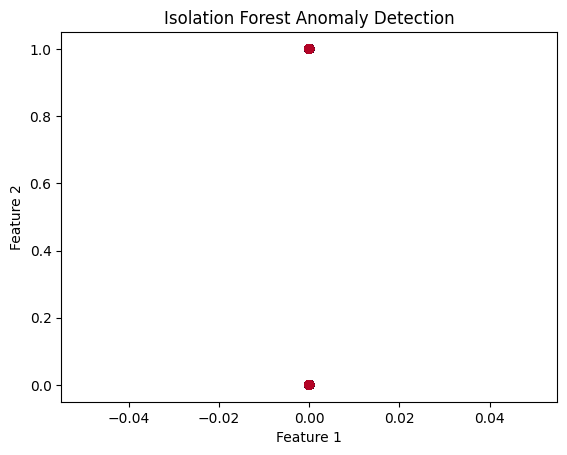

In [80]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

df_final['bucket'] = df_final['bucket'].apply(lambda x: 1 if x == "Morning" else (2 if x == "Business" else (3 if x == "Evening" else 0)))
model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42)
model.fit(df_final.drop(columns=["date", "user", "pc"]))

df_final['anomaly'] = model.predict(df_final.drop(columns=["date", "user", "pc"]))
df_final['scores'] = model.decision_function(df_final.drop(columns=["date", "user", "pc", "anomaly"]))

outliers = df_final[df_final['anomaly'] == -1]
print(df_final['user'].nunique())
print(outliers['user'].unique())

plt.scatter(df_final['bucket'], df_final['known_device'], c=df_final['anomaly'], cmap='coolwarm', label='Data')
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


To do: calculate SD for file size, email size, counts per user. 

In [84]:
import os
sus_users = [x.split("-1-")[1].split(".")[0] for x in os.listdir("C:\\Users\\mj4059\\Downloads\\answers\\answers\\r5.2-1")]
print(sus_users)
print(set(sus_users) - set(df_logon['user'].to_list()))


['ALT1465', 'ALW0764', 'AYG1697', 'DAS1320', 'DNJ0740', 'ELT1370', 'EPG1196', 'ETW0002', 'FZG0389', 'GFM1815', 'IHC0561', 'ISW0738', 'JKB0287', 'JUP1472', 'KBC1390', 'KEW0198', 'MIB0203', 'NIV1608', 'PBC0077', 'PTH0005', 'REF1924', 'SAF1942', 'SLL0193', 'TMC0934', 'VAH1292', 'WHB1247', 'WSK1857', 'WWW0701', 'ZKP0542']
set()


In [89]:
del df_logon
df_logon = pd.read_csv("C:\\Users\\mj4059\\Downloads\\r5.2\\r5.2\\logon.csv")
df_logon['date'] = pd.to_datetime(df_logon['date'])
df_logon['hour'] = df_logon['date'].dt.hour
df_logon['bucket'] = pd.cut(df_logon['hour'], bins=[0, 6, 10, 18, 24], labels=[-0.8, 0.3, 0.9, 0.1], right=False)
df_logon['known_device'] = 0
df_logon = df_logon.sort_values(by=['user', 'date'])
df_logon.loc[df_logon.duplicated(subset=['user', 'pc'], keep='first'), 'known_device'] = 1

def update_kd(group):
    if len(group) > 400 and group.iloc[0] == 0 and (group.iloc[1:] == 1).all():
        group.iloc[0] = 1
    return group

df_logon['known_device'] = df_logon.groupby(['user', 'pc'])['known_device'].transform(update_kd)
df_logon_sus = df_logon[df_logon['user'].isin(sus_users)]
df_logon_normal = df_logon[~df_logon['user'].isin(sus_users)]

df_logon_normal['total_logon_per_user'] = df_logon_normal[df_logon_normal['activity'] == "Logon"].groupby([df_logon_normal['date'].dt.date, df_logon_normal['user']])['activity'].transform('count')
df_logon_normal['total_logon_per_user'] = df_logon_normal['total_logon_per_user'].fillna(0)
df_logon_normal['total_logoff_per_user'] = df_logon_normal[df_logon_normal['activity'] == "Logoff"].groupby([df_logon_normal['date'].dt.date, df_logon_normal['user']])['activity'].transform('count')
df_logon_normal['total_logoff_per_user'] = df_logon_normal['total_logoff_per_user'].fillna(0)
df_logon_normal['total_logon_per_user_bucket'] = df_logon_normal[df_logon_normal['activity'] == "Logon"].groupby([df_logon_normal['date'].dt.date, df_logon_normal['user'], df_logon_normal['bucket']])['activity'].transform('count')
df_logon_normal['total_logon_per_user_bucket'] = df_logon_normal['total_logon_per_user_bucket'].fillna(0)
df_logon_normal['total_logoff_per_user_bucket'] = df_logon_normal[df_logon_normal['activity'] == "Logoff"].groupby([df_logon_normal['date'].dt.date, df_logon_normal['user'], df_logon_normal['bucket']])['activity'].transform('count')
df_logon_normal['total_logoff_per_user_bucket'] = df_logon_normal['total_logoff_per_user_bucket'].fillna(0)
df_logon_normal['total_activity_per_user'] = df_logon_normal['total_logon_per_user'] + df_logon_normal['total_logoff_per_user']
df_logon_normal['total_activity_per_user_bucket'] = df_logon_normal['total_logon_per_user_bucket'] + df_logon_normal['total_logoff_per_user_bucket']

df_logon_normal["zscore_logon_per_user"] = df_logon_normal[df_logon_normal['activity'] == "Logon"].groupby([df_logon_normal['user']])['total_logon_per_user'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_normal["zscore_logoff_per_user"] = df_logon_normal[df_logon_normal['activity'] == "Logoff"].groupby([df_logon_normal['user']])['total_logoff_per_user'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_normal["zscore_logon_per_user_per_bucket"] = df_logon_normal[df_logon_normal['activity'] == "Logon"].groupby([df_logon_normal['user'], df_logon_normal['bucket']])['total_logon_per_user_bucket'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_normal["zscore_logoff_per_user_per_bucket"] = df_logon_normal[df_logon_normal['activity'] == "Logoff"].groupby([df_logon_normal['user'], df_logon_normal['bucket']])['total_logoff_per_user_bucket'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_normal["zscore_activity_per_user"] = df_logon_normal.groupby([df_logon_normal['user']])['total_activity_per_user'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_normal["zscore_activity_per_user_per_bucket"] = df_logon_normal.groupby([df_logon_normal['user'], df_logon_normal['bucket']])['total_activity_per_user_bucket'].transform(lambda x: (x - x.mean()) / x.std())


df_logon_normal = df_logon_normal.drop_duplicates(subset=['user', 'date', 'bucket', 'pc'], keep='first')
df_logon_normal.drop(columns=['total_logon_per_user', 'total_logoff_per_user', 'total_logon_per_user_bucket', 'total_logoff_per_user_bucket', 'total_activity_per_user', 'total_activity_per_user_bucket', 'id', 'pc', 'activity'], inplace=True)
df_logon_normal.fillna(0, inplace=True)

df_logon_sus['total_logon_per_user'] = df_logon_sus[df_logon_sus['activity'] == "Logon"].groupby([df_logon_sus['date'].dt.date, df_logon_sus['user']])['activity'].transform('count')
df_logon_sus['total_logon_per_user'] = df_logon_sus['total_logon_per_user'].fillna(0)
df_logon_sus['total_logoff_per_user'] = df_logon_sus[df_logon_sus['activity'] == "Logoff"].groupby([df_logon_sus['date'].dt.date, df_logon_sus['user']])['activity'].transform('count')
df_logon_sus['total_logoff_per_user'] = df_logon_sus['total_logoff_per_user'].fillna(0)
df_logon_sus['total_logon_per_user_bucket'] = df_logon_sus[df_logon_sus['activity'] == "Logon"].groupby([df_logon_sus['date'].dt.date, df_logon_sus['user'], df_logon_sus['bucket']])['activity'].transform('count')
df_logon_sus['total_logon_per_user_bucket'] = df_logon_sus['total_logon_per_user_bucket'].fillna(0)
df_logon_sus['total_logoff_per_user_bucket'] = df_logon_sus[df_logon_sus['activity'] == "Logoff"].groupby([df_logon_sus['date'].dt.date, df_logon_sus['user'], df_logon_sus['bucket']])['activity'].transform('count')
df_logon_sus['total_logoff_per_user_bucket'] = df_logon_sus['total_logoff_per_user_bucket'].fillna(0)
df_logon_sus['total_activity_per_user'] = df_logon_sus['total_logon_per_user'] + df_logon_sus['total_logoff_per_user']
df_logon_sus['total_activity_per_user_bucket'] = df_logon_sus['total_logon_per_user_bucket'] + df_logon_sus['total_logoff_per_user_bucket']

df_logon_sus["zscore_logon_per_user"] = df_logon_sus[df_logon_sus['activity'] == "Logon"].groupby([df_logon_sus['user']])['total_logon_per_user'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_sus["zscore_logoff_per_user"] = df_logon_sus[df_logon_sus['activity'] == "Logoff"].groupby([df_logon_sus['user']])['total_logoff_per_user'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_sus["zscore_logon_per_user_per_bucket"] = df_logon_sus[df_logon_sus['activity'] == "Logon"].groupby([df_logon_sus['user'], df_logon_sus['bucket']])['total_logon_per_user_bucket'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_sus["zscore_logoff_per_user_per_bucket"] = df_logon_sus[df_logon_sus['activity'] == "Logoff"].groupby([df_logon_sus['user'], df_logon_sus['bucket']])['total_logoff_per_user_bucket'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_sus["zscore_activity_per_user"] = df_logon_sus.groupby([df_logon_sus['user']])['total_activity_per_user'].transform(lambda x: (x - x.mean()) / x.std())
df_logon_sus["zscore_activity_per_user_per_bucket"] = df_logon_sus.groupby([df_logon_sus['user'], df_logon_sus['bucket']])['total_activity_per_user_bucket'].transform(lambda x: (x - x.mean()) / x.std())


df_logon_sus = df_logon_sus.drop_duplicates(subset=['user', 'date', 'bucket', 'pc'], keep='first')
df_logon_sus.drop(columns=['total_logon_per_user', 'total_logoff_per_user', 'total_logon_per_user_bucket', 'total_logoff_per_user_bucket', 'total_activity_per_user', 'total_activity_per_user_bucket', 'id', 'pc', 'activity'], inplace=True)
df_logon_sus.fillna(0, inplace=True)


,date,user,hour,bucket,known_device,zscore_logon_per_user,zscore_logoff_per_user,zscore_logon_per_user_per_bucket,zscore_logoff_per_user_per_bucket,zscore_activity_per_user,zscore_activity_per_user_per_bucket
2824,2010-01-04 09:00:00,ALT1465,9,0.3,1,1.478489,0.000000,-0.348265,0.000000,1.643621,-0.337194
3452,2010-01-04 14:07:55,ALT1465,14,0.9,1,1.478489,0.000000,1.565181,0.000000,1.643621,1.781628
3538,2010-01-04 15:02:05,ALT1465,15,0.9,0,1.478489,0.000000,1.565181,0.000000,1.643621,1.781628
3544,2010-01-04 15:07:26,ALT1465,15,0.9,1,0.000000,0.839741,0.000000,-0.447542,0.007927,-0.559519
4836,2010-01-04 18:08:00,ALT1465,18,0.1,1,0.000000,0.839741,0.000000,-0.296617,0.007927,-0.290296
...,...,...,...,...,...,...,...,...,...,...,...
1413356,2011-02-02 14:46:00,ZKP0542,14,0.9,1,0.000000,-0.120388,0.000000,0.000000,-0.134965,0.000000
1415621,2011-02-03 06:46:00,ZKP0542,6,0.3,1,-0.147984,0.000000,0.000000,0.000000,-0.134965,0.000000
1418051,2011-02-03 14:43:00,ZKP0542,14,0.9,1,0.000000,-0.120388,0.000000,0.000000,-0.134965,0.000000
1420379,2011-02-04 06:35:00,ZKP0542,6,0.3,1,-0.147984,0.000000,0.000000,0.000000,-0.134965,0.000000


In [96]:
df_logon_normal.info()

<class 'pandas.DataFrame'>
Index: 1792964 entries, 123 to 1808671
Data columns (total 11 columns):
 #   Column                               Dtype         
---  ------                               -----         
 0   date                                 datetime64[us]
 1   user                                 str           
 2   hour                                 int32         
 3   bucket                               category      
 4   known_device                         int64         
 5   zscore_logon_per_user                float64       
 6   zscore_logoff_per_user               float64       
 7   zscore_logon_per_user_per_bucket     float64       
 8   zscore_logoff_per_user_per_bucket    float64       
 9   zscore_activity_per_user             float64       
 10  zscore_activity_per_user_per_bucket  float64       
dtypes: category(1), datetime64[us](1), float64(6), int32(1), int64(1), str(1)
memory usage: 209.8 MB


In [100]:
import matplotlib.pyplot as plt
import tensorflow.keras.models as Model
import tensorflow as tf
import numpy as np

from sklearn.model_selection import train_test_split

df_logon_normal['isSus'] = 0
df_logon_sus['isSus'] = 1
train_data, test_data, train_label, test_label = train_test_split(df_logon_normal.drop(columns=['user', 'bucket', 'date', 'hour', 'isSus']), df_logon_normal['isSus'][:], test_size=0.2, random_state=42)

test_data = pd.concat([test_data, df_logon_sus.drop(columns=['user', 'bucket', 'date', 'hour', 'isSus'])])
test_label = pd.concat([test_label, df_logon_sus['isSus']])

TimeSteps = 7

def create_seq(X, y, time_steps=TimeSteps):
    X_out, y_out = [], []
    for i in range(len(X) - time_steps):
        X_out.append(X.iloc[i:(i + time_steps)].values)
        y_out.append(y.iloc[i + time_steps])
    return np.array(X_out), np.array(y_out)

X_train, y_train = create_seq(train_data, train_label)
X_test, y_test = create_seq(test_data, test_label)

print("Training input shape:", X_train.shape)
print("Testing input shape:", X_test.shape)



Training input shape: (1434364, 7, 7)
Testing input shape: (375692, 7, 7)


In [103]:
np.random.seed(42)
tf.random.set_seed(42)

n_features = X_train.shape[2]
window_size = X_train.shape[1]

model = Model.Sequential([
    # ENCODER: Learns the pattern summary
    tf.keras.layers.LSTM(64, activation='relu', input_shape=(window_size, n_features), return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    # BRIDGE: Repeats the summary for each time step in the window
    tf.keras.layers.RepeatVector(window_size),
    
    # DECODER: Reconstructs the original features
    tf.keras.layers.LSTM(64, activation='relu', return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_features))
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

model.summary()

c:\Personal\projects\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 7, 7)           │           455 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,911 (202.78 KB)

 Trainable params: 51,911 (202.78 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
normal_action = model.fit(X_train, X_train,
                          epochs=50,
                          batch_size=32,
                          validation_split=0.1,
                          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, mode='min')],
                          shuffle=False)

Epoch 1/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 209s 5ms/step - loss: 0.5414 - val_loss: 0.3541
Epoch 2/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 210s 5ms/step - loss: 0.4057 - val_loss: 0.2858
Epoch 3/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 205s 5ms/step - loss: 0.2465 - val_loss: 0.1620
Epoch 4/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 211s 5ms/step - loss: 0.2098 - val_loss: 0.1140
Epoch 5/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 277s 7ms/step - loss: 1.8984 - val_loss: 0.0959
Epoch 6/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 306s 8ms/step - loss: 0.7916 - val_loss: 0.2421
Epoch 7/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 306s 8ms/step - loss: 0.4447 - val_loss: 0.1029
Epoch 8/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 319s 8ms/step - loss: 0.2088 - val_loss: 0.0823
Epoch 9/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 307s 8ms/step - loss: 0.1055 - val_loss: 0.0638
Epoch 10/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 297s 7ms/step - loss: 0.1018 - val_loss: 0.0614
Epoch 11/50
40342/40342 ━━━━━━━━━━━━━━━━━━━━ 301s 7ms/step - loss: 0.0992 - val

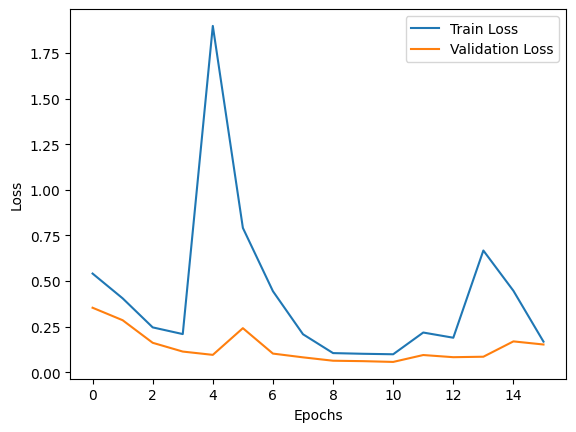

In [108]:
plt.plot(normal_action.history['loss'], label='Train Loss')
plt.plot(normal_action.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

44824/44824 ━━━━━━━━━━━━━━━━━━━━ 113s 3ms/step


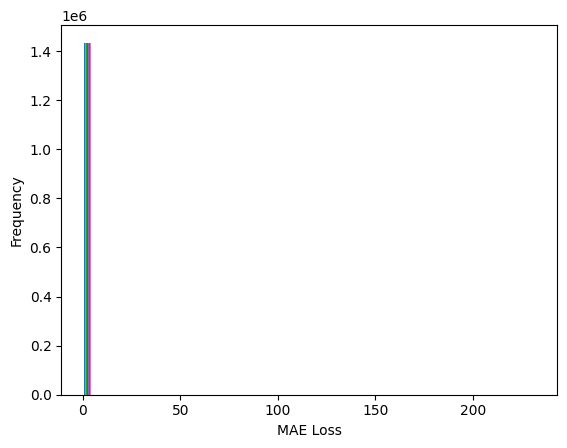

In [109]:
reconstruct = model.predict(X_train)
train_loss = tf.keras.losses.mae(reconstruct, X_train)
mean = np.mean(train_loss)

plt.hist(train_loss, bins=50)
plt.xlabel('MAE Loss')
plt.ylabel('Frequency')
plt.show()

11741/11741 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step


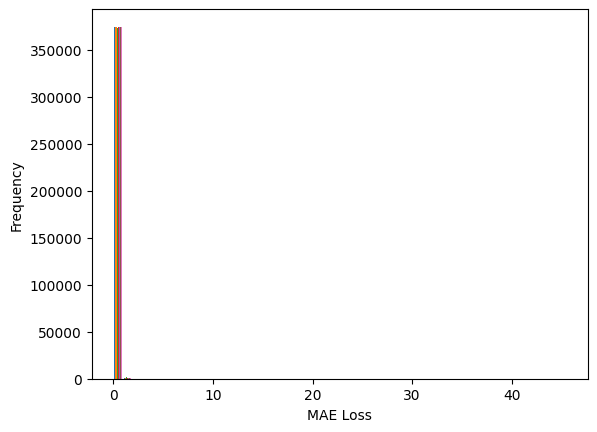

In [110]:
threshold = np.max(train_loss)
reconstruct = model.predict(X_test)
test_loss = tf.keras.losses.mae(reconstruct, X_test)
mean = np.mean(test_loss)

plt.hist(test_loss, bins=50)
plt.xlabel('MAE Loss')
plt.ylabel('Frequency')
plt.show()